# Stochastic Mixture of Experts

This notebook constructs a stochastic mixture-of-experts (MoE) model for observations of

$$y(x) = \sin(\pi x) + \operatorname{sign}(x) + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, 0.05^2)$$

The surrogate combines two polynomial chaos experts whose outputs are blended by a neural gating network so that the predictive mean is

$$\hat{y}(x) = \sum_{m=1}^{M} \pi_m(x) f_m(x)$$

with stochastic parameters in both experts and the gate.

In [1]:
# Import statements
import matplotlib.pyplot as plt
import torch

from pypolymix.parameter_groups import DeterministicGroup, IIDGaussianGroup
from pypolymix.surrogate_models import PolynomialChaosExpansion, MixtureOfExperts, GatingNetwork
from pypolymix import StochasticModel

In [2]:
# Set random seed
_ = torch.manual_seed(1234)

We sample `num_samples = 50` inputs in $[-1, 1]$ and compute targets using $y_i = \sin(\pi x_i) + \operatorname{sign}(x_i) + \varepsilon_i$. The discontinuity at $x=0$ motivates the use of multiple experts.

In [3]:
# Generate synthetic data
num_samples = 50
X = 2 * torch.rand(num_samples, 1) - 1
Y = torch.sin(torch.pi * X) + torch.sign(X) + 0.05 * torch.randn(X.shape)

A scatter plot shows the two regimes induced by the sign term. It is clear that a single smooth model is insufficient to capture this data set.

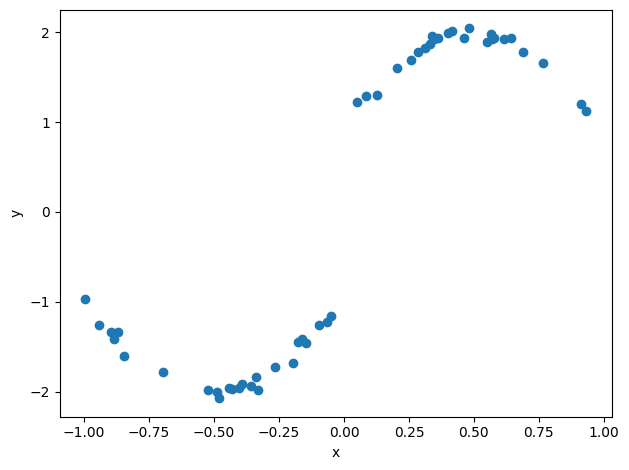

In [4]:
# Plot synthetic data
_, ax = plt.subplots()
ax.scatter(X, Y)
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()

We instantiate two cubic `PolynomialChaosExpansion` experts and a `tanh`-activated `GatingNetwork` with width 16 and depth 1. Printing `num_params` reveals how many stochastic coefficients the joint model contains.

In [5]:
# Create a surrogate model
width = 16
depth = 1
surrogate_model = MixtureOfExperts(
    experts=[
        PolynomialChaosExpansion(num_inputs=1, num_outputs=1, degree=3),
        PolynomialChaosExpansion(num_inputs=1, num_outputs=1, degree=3),
    ],
    gating_network=GatingNetwork(num_inputs=1, num_experts=2, width=width, depth=depth, activation=torch.nn.functional.tanh)
)

num_params = surrogate_model.num_params()
print(f"This model has {num_params} parameters")

This model has 74 parameters


Each chaos expert has a split between stochastic (`IIDGaussianGroup`) and deterministic coefficients, while the gating network layers are grouped so their weights and biases can either remain deterministic or follow Gaussian priors. This structure controls which parts of the MoE carry epistemic uncertainty.

In [6]:
# Create parameter groups
parameter_groups = [  # Experts
    IIDGaussianGroup("expert1_c0", 2),
    DeterministicGroup("expert1_c", 2),
    IIDGaussianGroup("expert2_c0", 2),
    DeterministicGroup("expert2_c", 2),
]
# Gating network
parameter_groups += [  # Input layer
    DeterministicGroup("gating_input_layer_weights", width),
    DeterministicGroup("gating_input_layer_biases", width),
]
for j in range(depth - 1):
    parameter_groups += [  # Hidden layers
        DeterministicGroup(f"gating_layer{j + 1}_weights", width * width),
        DeterministicGroup(f"gating_layer{j + 1}_biases", width),
    ]
parameter_groups += [  # Output layer
    IIDGaussianGroup("gating_output_weights", 2 * width),
    IIDGaussianGroup("gating_output_biases", 2),
]

`StochasticModel` fuses the surrogate with the parameter priors so we can sample expert/gate parameters jointly and compute their distribution regularizer during training.

In [7]:
# Create stochastic model
model = StochasticModel(
    surrogate_model=surrogate_model, parameter_groups=parameter_groups
)
print(f"Created stochastic model with {model.num_params()} parameters")

Created stochastic model with 74 parameters


Specify training hyperparameters.

In [8]:
# Training options
lr = 1e-2             # Learning rate
weight_decay = 1e-4   # Weight decay for AdamW
weight_factor = 1e-1  # Weight factor for distribution loss
num_epochs = 10000    # Number of epochs
num_samples = 100     # Number of parameter samples per epoch

# Learnable global precision
log_tau = torch.nn.Parameter(torch.tensor(0.0))  # τ = exp(log_tau)

# Optimizer: AdamW
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

# Loss
loss_fn = torch.nn.MSELoss(reduction="sum")

# Scheduler: OneCycleLR
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=10 * lr,
    total_steps=num_epochs
)

Each epoch draws 100 parameter samples, evaluates the MoE on the training inputs, evaluates the data loss and adds the distribution regularizer weighted by `weight_factor`, and performs the optimizer and scheduler steps.

In [9]:
# Train the stochastic model
for epoch in range(num_epochs):
    optimizer.zero_grad()

    # Evaluate parameters and model
    params = model.sample_parameters(num_samples=100)
    Y_hat = surrogate_model(X, params)

    # Losses
    data_loss = loss_fn(Y_hat, Y.unsqueeze(0).expand_as(Y_hat)) / num_samples
    distribution_loss = model.distribution_loss()
    total_loss = data_loss + weight_factor * distribution_loss

    # Backprop + step
    total_loss.backward()
    optimizer.step()
    scheduler.step()

    # Logging
    if (epoch + 1) % 1000 == 0:
        current_lr = scheduler.get_last_lr()[0]
        print(
            f"Epoch {epoch + 1:5d} | "
            f"learning rate = {current_lr:.6f} | "
            f"data loss = {data_loss.item():.4f} | "
            f"distribution loss = {distribution_loss.item():.4f} | "
            f"total loss = {total_loss.item():.4f}"
        )

Epoch  1000 | learning rate = 0.028015 | data loss = 8.0579 | distribution loss = 69.4361 | total loss = 15.0015
Epoch  2000 | learning rate = 0.076029 | data loss = 6.9081 | distribution loss = 55.0426 | total loss = 12.4124
Epoch  3000 | learning rate = 0.100000 | data loss = 1.0801 | distribution loss = 62.7656 | total loss = 7.3567
Epoch  4000 | learning rate = 0.095039 | data loss = 1.0363 | distribution loss = 62.4390 | total loss = 7.2802
Epoch  5000 | learning rate = 0.081157 | data loss = 1.1154 | distribution loss = 62.2607 | total loss = 7.3415
Epoch  6000 | learning rate = 0.061104 | data loss = 1.0450 | distribution loss = 62.3786 | total loss = 7.2829
Epoch  7000 | learning rate = 0.038852 | data loss = 1.1119 | distribution loss = 62.2398 | total loss = 7.3358
Epoch  8000 | learning rate = 0.018808 | data loss = 1.0815 | distribution loss = 62.1805 | total loss = 7.2996
Epoch  9000 | learning rate = 0.004942 | data loss = 1.0852 | distribution loss = 62.2581 | total loss

With the model in eval mode we create 100 evenly spaced test inputs and sample 1000 stochastic forward passes to estimate the predictive distribution of the MoE across the interval.

In [10]:
# Evaluate the model
model.eval()
with torch.no_grad():
    X_test = torch.linspace(-1, 1, 100).unsqueeze(1)
    Y_test = model(X_test, num_samples=1000)

Quantiles of the sampled outputs form a shaded credible band and the sample mean gives the red curve, which we overlay with the raw training data to judge fit and uncertainty.

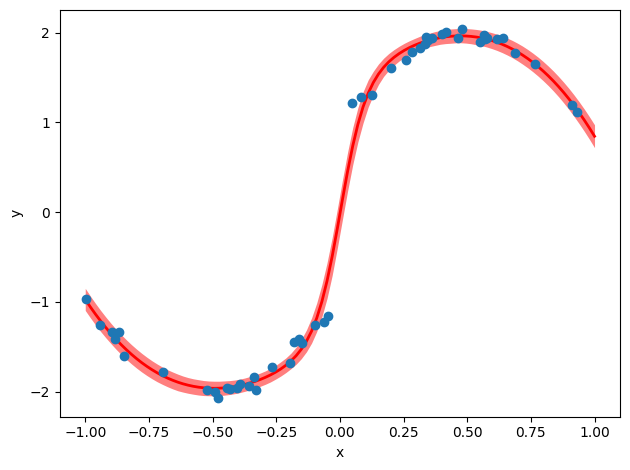

In [11]:
# Plot prediction
_, ax = plt.subplots()
Q_test = torch.quantile(Y_test, torch.tensor([0.1, 0.9]), axis=0)
X_plot = X_test.squeeze(-1)
Q_plot = Q_test.squeeze(-1)
ax.fill_between(X_plot, Q_plot[0], Q_plot[-1], color="red", alpha=0.5, linewidth=0)
M_plot = Y_test.mean(axis=0).squeeze(-1)
ax.plot(X_plot, M_plot, color="red", linewidth=2)
ax.scatter(X, Y, zorder=99)
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()

Using `get_gating_weights` we directly query the probabilistic gating network on the test grid, which yields the random mixing coefficients $\pi_m(x)$ for each expert.

In [12]:
# Evaluate the gating probabilities
with torch.no_grad():
    params = model.sample_parameters(1000)
    gating_weights = surrogate_model.get_gating_weights(X_test, params)

We plot the median and 80% interval of the gating probabilities so it is clear how responsibility shifts between experts as $x$ crosses zero.

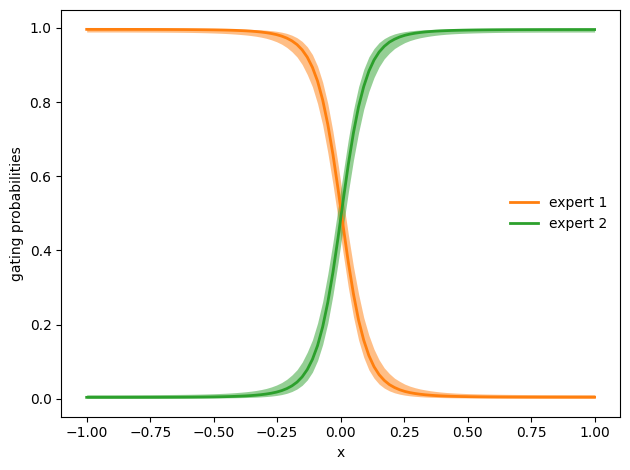

In [13]:
# Plot gating probabilities
_, ax = plt.subplots()
for expert in range(2):
    Q_test = torch.quantile(gating_weights[:, :, expert], torch.tensor([0.1, 0.5, 0.9]), axis=0)
    X_plot = X_test.squeeze(-1)
    Q_plot = Q_test.squeeze(-1)
    # ax.plot(gating_weights[:, :, expert])
    ax.fill_between(X_plot, Q_plot[0], Q_plot[-1], color=f"C{expert + 1}", alpha=0.5, linewidth=0)
    ax.plot(X_plot, Q_plot[1], color=f"C{expert + 1}", linewidth=2, label=f"expert {expert + 1}")
ax.set_xlabel("x")
ax.set_ylabel("gating probabilities")
ax.legend(frameon=False)
plt.tight_layout()

`get_expert_outputs` evaluates each expert separately (still under parameter uncertainty) so we can inspect what functions the gate is blending together.

In [14]:
# Evaluate the expert outputs
with torch.no_grad():
    params = model.sample_parameters(1000)
    expert_outputs = surrogate_model.get_expert_outputs(X_test, params)

Filling between quantiles of each expert’s predictions, along with their means and the observed data, shows how the experts divide the regression task and how their uncertainty compares.

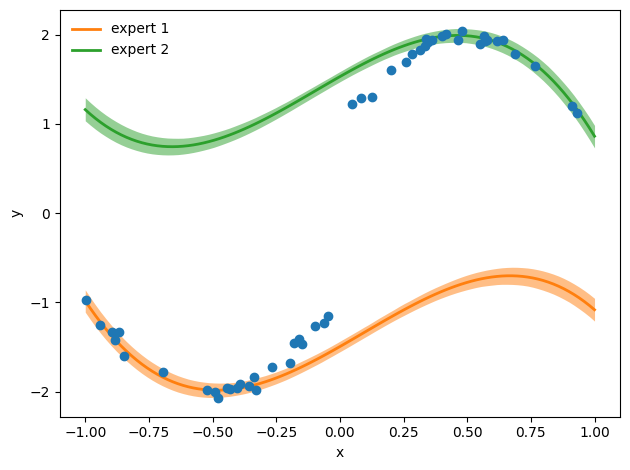

In [15]:
# Plot expert outputs
_, ax = plt.subplots()
ax.scatter(X, Y, zorder=99)
for expert in range(2):
    Q_test = torch.quantile(expert_outputs[:, expert, :, :], torch.tensor([0.1, 0.5, 0.9]), axis=0)
    X_plot = X_test.squeeze(-1)
    Q_plot = Q_test.squeeze(-1)
    ax.fill_between(X_plot, Q_plot[0], Q_plot[-1], color=f"C{expert + 1}", alpha=0.5, linewidth=0)
    M_plot = expert_outputs[:, expert, :, :].mean(axis=0).squeeze(-1)
    ax.plot(X_plot, M_plot, color=f"C{expert + 1}", linewidth=2, label=f"expert {expert + 1}")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(frameon=False)
plt.tight_layout()